# 06a — Lập chỉ mục và xử lý câu truy vấn

Hạng mục 5.

Mọi notebook từ `02` tới `05` đều gọi `RetrievalIndex` mà chưa lần nào mở nó ra
xem bên trong. Notebook này làm việc đó.

### Ba câu hỏi

| # | Câu hỏi | Trả lời ở mục |
| --- | --- | --- |
| 1 | Chỉ mục ngược là cấu trúc gì, chứa cái gì | 1, 3 |
| 2 | Một câu truy vấn đi qua những bước nào | 5 |
| 3 | Chỉ mục nhanh hơn cách quét toàn bộ bao nhiêu lần | 6 |

Câu 3 là câu đáng đo nhất. Bộ công cụ của ban tổ chức có sẵn một bản cài đặt
quét toàn bộ (`reference_bm25_search`), nên so được trực tiếp trên cùng dữ liệu
thay vì trích dẫn lý thuyết.

### Đầu ra

| Tệp | Nội dung |
| --- | --- |
| `results/indexing.json` | Kích thước, thời gian dựng, thống kê từ vựng của 13 nhóm |

---

## 1. Chỉ mục ngược là gì

Có hai cách sắp xếp cùng một kho văn bản.

**Cách thứ nhất, theo tài liệu.** Đây là cách file `documents.jsonl` đang lưu:

```text
tài liệu 1  →  "bitcoin price rose after the update"
tài liệu 2  →  "the update changed the fee"
tài liệu 3  →  "bitcoin fee bitcoin"
```

Muốn tìm tài liệu chứa từ `bitcoin` thì phải **đọc hết mọi tài liệu**.

**Cách thứ hai, theo từ.** Đảo bảng trên lại:

```text
bitcoin  →  (tài liệu 1, 1 lần)   (tài liệu 3, 2 lần)
update   →  (tài liệu 1, 1 lần)   (tài liệu 2, 1 lần)
fee      →  (tài liệu 2, 1 lần)   (tài liệu 3, 1 lần)
price    →  (tài liệu 1, 1 lần)
```

Muốn tìm tài liệu chứa `bitcoin` thì đọc đúng một dòng.

Đó là **chỉ mục ngược**. Gọi là "ngược" vì nó đảo chiều quan hệ: thay vì
tài liệu → từ, nó lưu từ → tài liệu.

Mỗi dòng gọi là một **danh sách vị trí** (posting list).

### Trong dự án này nó là ma trận thưa

`RetrievalIndex` lưu chỉ mục dưới dạng ma trận **từ × tài liệu**, chỉ giữ những
ô khác 0:

```text
              tài liệu 1   tài liệu 2   tài liệu 3
  bitcoin         1            ·             2
  update          1            1             ·
  fee             ·            1             1
  price           1            ·             ·
```

Dấu `·` là ô bằng 0, không được lưu. Kho của `history` có 356.000 tài liệu và
khoảng 300.000 từ khác nhau, tức hơn 10^11 ô. Lưu hết là bất khả thi. Nhưng
mỗi tài liệu chỉ chứa vài trăm từ khác nhau, nên số ô khác 0 chỉ khoảng 10^7 —
ít hơn mười nghìn lần.

Định dạng lưu gọi là CSR. Nó giữ ba dãy số:

| Dãy | Chứa gì |
| --- | --- |
| `data` | Giá trị của từng ô khác 0 |
| `indices` | Ô đó thuộc tài liệu nào |
| `indptr` | Dòng của mỗi từ bắt đầu ở đâu trong hai dãy trên |

Nhờ `indptr`, lấy danh sách vị trí của một từ chỉ là phép cắt dãy.

---

## 2. Nạp thư viện

In [10]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = R.list_domains(DATA)

TOKENIZER = R.make_tokenizer(drop_html=True, stopwords=R.EXTENDED_STOPWORDS)

import re
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_ENTITY.sub(" ", HTML_TAG.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


def query_form(text):
    return strip_markup((title_of(text) + " ") * 3 + text)


# The configuration chosen in notebook 05.
K1, B = 2.0, 0.9

print(f"{len(domains)} domains, tokenizer nohtml_stop, bm25 k1={K1} b={B}")

13 domains, tokenizer nohtml_stop, bm25 k1=2.0 b=0.9


In [11]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

---

## 3. Dựng chỉ mục cho một nhóm và nhìn vào bên trong

Lấy nhóm có kho nhỏ nhất để chạy nhanh. Ô dưới in ra ba dãy số của CSR và vài
danh sách vị trí thật.

In [12]:
probe = min(domains, key=lambda d: (DATA / d / "documents.jsonl").stat().st_size)
doc_ids, doc_texts = R.load_corpus(DATA / probe / "documents.jsonl")

t0 = time.time()
index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=TOKENIZER,
                         weighting="bm25", k1=K1, b=B)
build_seconds = time.time() - t0

matrix = index.index                       # term-major CSR: rows are terms
print(f"domain            {probe}")
print(f"documents         {index.N:,}")
print(f"distinct terms    {len(index.vocab):,}")
print(f"non-zero cells    {matrix.nnz:,}")
print(f"build time        {build_seconds:.1f}s")
print()

full = index.N * len(index.vocab)
print(f"cells if stored as a dense table   {full:,}")
print(f"cells actually stored              {matrix.nnz:,}"
      f"   ({matrix.nnz / full:.2%})")
print()

megabyte = 1024 ** 2
for name, array in (("data    (the weights)", matrix.data),
                    ("indices (which document)", matrix.indices),
                    ("indptr  (where each term starts)", matrix.indptr)):
    print(f"  {name:<36}{array.nbytes / megabyte:>8.1f} MB"
          f"   {array.dtype}")
total = sum(a.nbytes for a in (matrix.data, matrix.indices, matrix.indptr))
print(f"  {'total':<36}{total / megabyte:>8.1f} MB")

domain            iota
documents         10,372
distinct terms    387,144
non-zero cells    2,046,706
build time        7.0s

cells if stored as a dense table   4,015,457,568
cells actually stored              2,046,706   (0.05%)

  data    (the weights)                   15.6 MB   float64
  indices (which document)                 7.8 MB   int32
  indptr  (where each term starts)         1.5 MB   int32
  total                                   24.9 MB


In [13]:
# What a posting list actually looks like, for a few terms of different
# frequency. The row of the matrix IS the posting list.
inverse_vocab = {j: term for term, j in index.vocab.items()}
document_frequency = index.df

order = np.argsort(-document_frequency)
# Four terms spread across the frequency range. dict.fromkeys drops duplicates,
# which is what a very small vocabulary would otherwise produce.
picks = list(dict.fromkeys([order[0], order[len(order) // 100],
                            order[len(order) // 2], order[-1]]))

print(f"{'term':<18}{'df':>8}{'share of corpus':>18}   first few documents")
print("-" * 86)
for j in picks:
    lo, hi = matrix.indptr[j], matrix.indptr[j + 1]
    docs = matrix.indices[lo:hi][:3]
    shown = ", ".join(index.doc_ids[d].split("/")[-1][:14] for d in docs)
    print(f"{inverse_vocab[j]:<18}{int(document_frequency[j]):>8}"
          f"{document_frequency[j] / index.N:>17.1%}   {shown}")
print("-" * 86)
print()
print("The most common term appears in a large share of the corpus; the rarest")
print("appears once. Section 6 shows what that spread costs a query.")

term                    df   share of corpus   first few documents
--------------------------------------------------------------------------------------
s                     4830            46.6%   470_68d2fff751, 311_abc2351bc1, 311_abc2351bc1
circulating            117             1.1%   d8e66ff0_0621., d8e66ff0_0340., d8e66ff0_0223.
kong1234                 1             0.0%   2714_a12e934e9
timestampedversionedvalue       1             0.0%   2194_8ee53355c
--------------------------------------------------------------------------------------

The most common term appears in a large share of the corpus; the rarest
appears once. Section 6 shows what that spread costs a query.


---

## 4. Chỉ mục của 13 nhóm

Dựng chỉ mục cho từng nhóm và ghi lại kích thước. Thời gian dự kiến:
**khoảng 10–15 phút**. Kết quả được lưu, chạy lại lần sau sẽ đọc từ tệp.

In [14]:
stats_file = CACHE / "indexing.json"

if stats_file.exists():
    stats = json.loads(stats_file.read_text(encoding="utf-8"))
    print("Loaded from cache. Delete results/indexing.json to rerun.")
else:
    stats = {}
    started = time.time()
    for i, domain in enumerate(domains, start=1):
        t0 = time.time()
        ids, texts = R.load_corpus(DATA / domain / "documents.jsonl")
        built = R.RetrievalIndex(ids, texts, tokenizer=TOKENIZER,
                                 weighting="bm25", k1=K1, b=B)
        seconds = time.time() - t0
        m = built.index
        stats[domain] = {
            "documents": built.N,
            "terms": len(built.vocab),
            "nonzeros": int(m.nnz),
            "tokens": float(built.doc_len.sum()),
            "avg_doc_length": float(built.avgdl),
            "bytes": int(m.data.nbytes + m.indices.nbytes + m.indptr.nbytes),
            "build_seconds": seconds,
        }
        del built, ids, texts
        print(f"  [{i:>2}/{len(domains)}] {domain:<12}{seconds:>6.0f}s", flush=True)
    stats_file.write_text(json.dumps(stats, indent=1), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

MB = 1024 ** 2
print(f"\n{'domain':<12}{'documents':>11}{'terms':>10}{'postings':>12}"
      f"{'index MB':>10}{'build s':>9}{'MB / 1k docs':>14}")
print("-" * 78)
for domain in sorted(stats, key=lambda d: -stats[d]["documents"]):
    s = stats[domain]
    print(f"{domain:<12}{s['documents']:>11,}{s['terms']:>10,}"
          f"{s['nonzeros']:>12,}{s['bytes'] / MB:>10.1f}"
          f"{s['build_seconds']:>9.0f}"
          f"{s['bytes'] / MB / (s['documents'] / 1000):>14.2f}")
print("-" * 78)
total_docs = sum(s["documents"] for s in stats.values())
total_bytes = sum(s["bytes"] for s in stats.values())
total_build = sum(s["build_seconds"] for s in stats.values())
print(f"{'TOTAL':<12}{total_docs:>11,}{'':>10}"
      f"{sum(s['nonzeros'] for s in stats.values()):>12,}"
      f"{total_bytes / MB:>10.1f}{total_build:>9.0f}")

Loaded from cache. Delete results/indexing.json to rerun.

domain        documents     terms    postings  index MB  build s  MB / 1k docs
------------------------------------------------------------------------------
history         356,493   920,022  52,902,546     608.9      203          1.71
hsm             213,818 1,032,518  28,658,677     331.9      130          1.55
politics        183,394   767,456  23,312,651     269.7      104          1.47
travel          177,677   944,827  19,878,236     231.1       51          1.30
genealogy       156,228 1,153,147  23,179,370     269.7       65          1.73
bitcoin         153,291   733,717  17,616,922     204.4       55          1.33
economics        93,756   545,175  11,204,870     130.3       30          1.39
cardano          87,201   617,988  11,561,694     134.7       33          1.54
monero           85,093   626,937  11,688,221     136.2       83          1.60
workplace        64,659   133,907   5,901,773      68.1       16        

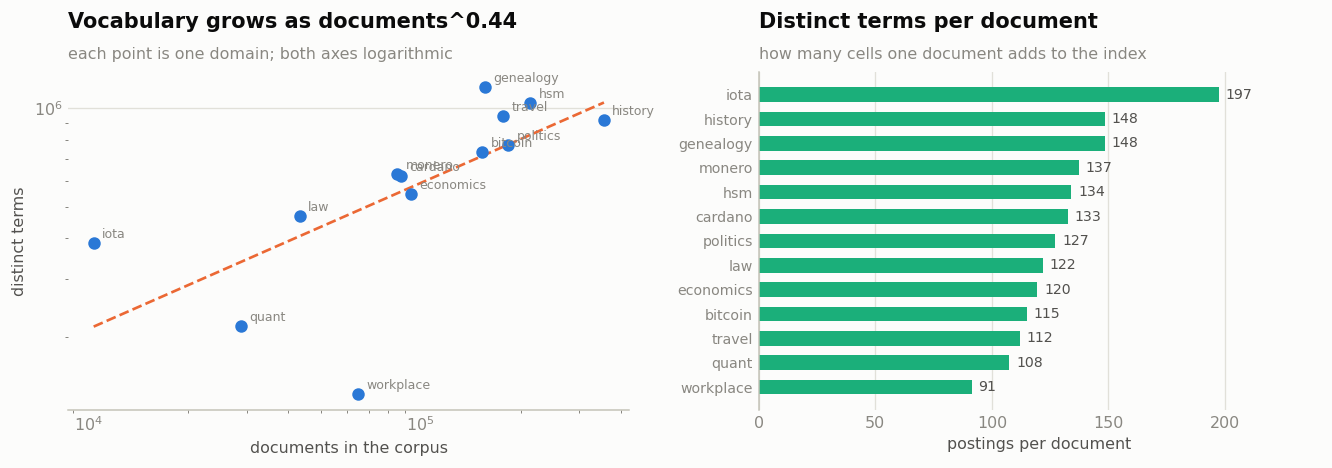

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))

documents = np.array([stats[d]["documents"] for d in domains], dtype=float)
terms = np.array([stats[d]["terms"] for d in domains], dtype=float)
postings = np.array([stats[d]["nonzeros"] for d in domains], dtype=float)

# --- left: vocabulary against corpus size -------------------------------
axes[0].scatter(documents, terms, s=42, color=BLUE, zorder=3)
for d, x, y in zip(domains, documents, terms):
    axes[0].annotate(d, (x, y), textcoords="offset points", xytext=(5, 3),
                     fontsize=7.5, color=INK_MUTED)
axes[0].set_xscale("log")
axes[0].set_yscale("log")

# Heaps' law says vocabulary grows as a power of corpus size. Fitting the
# exponent is one line and turns a claim into a measurement.
slope, intercept = np.polyfit(np.log(documents), np.log(terms), 1)
grid = np.linspace(documents.min(), documents.max(), 50)
axes[0].plot(grid, np.exp(intercept) * grid ** slope, color=ORANGE,
             linewidth=1.6, linestyle="--", zorder=2)
finish(axes[0],
       f"Vocabulary grows as documents^{slope:.2f}",
       "each point is one domain; both axes logarithmic",
       xlabel="documents in the corpus", ylabel="distinct terms",
       grid_axis="y")

# --- right: how many postings each document contributes ------------------
per_document = postings / documents
order = np.argsort(per_document)
y = np.arange(len(domains))
sorted_values = per_document[order].tolist()     # a list: label_bars tests it
bars = axes[1].barh(y, sorted_values, color=TEAL, height=0.6)
label_bars(axes[1], bars, sorted_values, fmt="{:.0f}")
axes[1].set_yticks(y)
axes[1].set_yticklabels([domains[i] for i in order], fontsize=8.5)
axes[1].set_xlim(0, per_document.max() * 1.22)
finish(axes[1], "Distinct terms per document",
       "how many cells one document adds to the index",
       xlabel="postings per document", grid_axis="x")

plt.tight_layout()
plt.show()

---

## 5. Một câu truy vấn đi qua những bước nào

Phần thứ hai của hạng mục 5. Ô dưới lấy một câu hỏi thật và in ra trạng thái
sau **từng bước**, thay vì mô tả bằng lời.

Sáu bước:

| # | Bước | Làm gì |
| --- | --- | --- |
| 1 | Dựng dạng câu hỏi | Ghép tiêu đề ba lần rồi bỏ thẻ HTML |
| 2 | Tách từ | Cắt thành từ, bỏ stopword và từ của HTML |
| 3 | Tra từ vựng | Đổi mỗi từ thành số thứ tự trong chỉ mục |
| 4 | Bỏ từ lạ | Từ không có trong kho thì bỏ, vì không tài liệu nào chứa |
| 5 | Đếm số lần | Từ lặp trong câu hỏi thì tính nhiều lần |
| 6 | Cộng điểm | Lấy các dòng tương ứng của chỉ mục rồi cộng có trọng số |

Bước 6 là chỗ chỉ mục ngược phát huy tác dụng: nó chỉ chạm vào các dòng của
những từ trong câu hỏi.

In [16]:
queries = R.load_queries(DATA / probe / "examples_train.jsonl")
query_id, raw = queries[0]

print(f"query id   {query_id}")
print(f"raw        {raw[:110].replace(chr(10), ' ')}...")
print()

# --- 1. query form --------------------------------------------------------
shaped = query_form(raw)
print(f"1  query form      {len(shaped):,} characters")
print(f"                   {shaped[:100]}...")

# --- 2. tokenise ----------------------------------------------------------
tokens = TOKENIZER(shaped)
print(f"\n2  tokenise        {len(tokens):,} tokens, "
      f"{len(set(tokens)):,} distinct")
print(f"                   {tokens[:12]}")

# --- 3 and 4. look up the vocabulary, drop unknown terms -----------------
known, unknown = [], []
for token in set(tokens):
    (known if token in index.vocab else unknown).append(token)
print(f"\n3  look up         {len(known):,} terms found in the index")
print(f"4  drop unknown    {len(unknown):,} terms appear nowhere in the corpus")
if unknown:
    print(f"                   {sorted(unknown)[:8]}")

# --- 5. count ------------------------------------------------------------
counts = {}
for token in tokens:
    j = index.vocab.get(token)
    if j is not None:
        counts[j] = counts.get(j, 0) + 1
repeated = sorted(counts.items(), key=lambda kv: -kv[1])[:5]
print(f"\n5  count           most repeated terms in this query:")
for j, n in repeated:
    print(f"                   {inverse_vocab[j]:<16} x{n}")

# --- 6. score ------------------------------------------------------------
rows = np.fromiter(counts.keys(), dtype=np.int64, count=len(counts))
posting_lengths = np.diff(index.index.indptr)[rows]
candidates = len(set(index.index[rows].indices))

print(f"\n6  score           {len(rows):,} posting lists read")
print(f"                   {posting_lengths.sum():,} postings touched in total")
print(f"                   {candidates:,} of {index.N:,} documents get a"
      f" non-zero score ({candidates / index.N:.1%})")
print()
top = index.search(shaped, top_k=5)
print(f"{'rank':<6}{'score':>10}   document")
for rank, (doc_id, score) in enumerate(top, start=1):
    print(f"{rank:<6}{score:>10.4f}   {doc_id}")

query id   2497_799
raw        How long do Zero Value Transactions last? <p>Let s say we have some critical information stored as Zero Value ...

1  query form      386 characters
                   How long do Zero Value Transactions last? How long do Zero Value Transactions last? How long do Zero...

2  tokenise        40 tokens, 19 distinct
                   ['long', 'zero', 'value', 'transactions', 'last', 'long', 'zero', 'value', 'transactions', 'last', 'long', 'zero']

3  look up         19 terms found in the index
4  drop unknown    0 terms appear nowhere in the corpus

5  count           most repeated terms in this query:
                   transactions     x6
                   long             x5
                   zero             x5
                   value            x5
                   last             x5

6  score           19 posting lists read
                   18,175 postings touched in total
                   7,953 of 10,372 documents get a non-zero score (76.7%

---

## 6. Nhanh hơn quét toàn bộ bao nhiêu

Bộ công cụ của ban tổ chức có sẵn `reference_bm25_search`: nó tính điểm cho
**mọi tài liệu**, bằng Python thuần, không dùng chỉ mục. Notebook `02` đã dùng
nó để kiểm chứng tính đúng đắn. Ở đây dùng nó để đo tốc độ.

Hai bản cho ra **kết quả giống hệt nhau** — điều này đã được kiểm ở `02` và
`04` — nên chênh lệch thời gian là chênh lệch thuần về cách tổ chức dữ liệu.

Chỉ chạy trên nhóm nhỏ. Bản quét toàn bộ trên `history` (356.000 tài liệu) sẽ
mất hàng chục giây cho **một** câu hỏi.

In [17]:
SAMPLE = 3

# The reference scores every document in Python. Keep the sample small.
reference_index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=R.tokenize_simple,
                                   weighting="bm25", k1=0.9, b=0.4)

print(f"domain {probe}, {len(doc_ids):,} documents, {SAMPLE} queries\n")
print(f"{'method':<26}{'seconds / query':>18}{'documents scored':>20}")
print("-" * 64)

t0 = time.time()
for _, text in queries[:SAMPLE]:
    R.reference_bm25_search(doc_ids, doc_texts, query_form(text), top_k=100)
linear_seconds = (time.time() - t0) / SAMPLE

t0 = time.time()
for _, text in queries[:SAMPLE]:
    reference_index.search(query_form(text), top_k=100)
index_seconds = (time.time() - t0) / SAMPLE

print(f"{'scan every document':<26}{linear_seconds:>18.3f}{len(doc_ids):>20,}")
print(f"{'inverted index':<26}{index_seconds:>18.3f}"
      f"{'only matching ones':>20}")
print("-" * 64)
# A timer can read zero on a very small corpus; say so rather than dividing.
if index_seconds > 0:
    print(f"\nspeed-up: {linear_seconds / index_seconds:.0f}x on this domain")
else:
    print("\nthe indexed search was too fast for the timer to measure")
print()
print("The scan re-tokenises every document for every query, which is most of")
print("its cost. The index pays that price once, when it is built.")

# Scale to the whole project, using each domain's OWN query count. Taking one
# domain's document count and multiplying by all 1,211 queries would describe a
# run nobody performs.
per_document = linear_seconds / len(doc_ids)
split_file = json.loads((CACHE / "split.json").read_text(encoding="utf-8"))
scan_seconds = sum(
    (len(split_file[d]["fit"]) + len(split_file[d]["check"]))
    * stats[d]["documents"] * per_document
    for d in stats)
index_seconds_total = sum(s["build_seconds"] for s in stats.values())

print()
print("Cost of one pass over all 13 domains, 1,211 queries:")
print(f"  scan every document   {scan_seconds / 3600:>8.0f} hours")
print(f"  build every index     {index_seconds_total / 60:>8.0f} minutes")
print(f"  ratio                 {scan_seconds / index_seconds_total:>8,.0f}x")

del reference_index

domain iota, 10,372 documents, 3 queries

method                       seconds / query    documents scored
----------------------------------------------------------------
scan every document                    5.751              10,372
inverted index                         0.002  only matching ones
----------------------------------------------------------------

speed-up: 2471x on this domain

The scan re-tokenises every document for every query, which is most of
its cost. The index pays that price once, when it is built.

Cost of one pass over all 13 domains, 1,211 queries:
  scan every document         45 hours
  build every index           14 minutes
  ratio                      200x


---

## 7. Vì sao nhanh

Mục 5 in ra tỉ lệ tài liệu được chấm điểm cho một câu hỏi. Con số đó quan trọng
hơn vẻ ngoài của nó.

Sách giáo khoa thường giải thích chỉ mục ngược nhanh vì nó **bỏ qua** phần lớn
tài liệu. Điều đó đúng với câu hỏi ngắn kiểu công cụ tìm kiếm, vài từ một câu.

Câu hỏi ở đây dài hàng trăm từ khác nhau. Gộp danh sách vị trí của ngần ấy từ
lại thì phần lớn kho đều có mặt. Ô dưới kiểm chứng điều đó trên nhiều câu hỏi.

In [18]:
touched = []
for _, text in queries:
    tokens = set(TOKENIZER(query_form(text)))
    rows = np.array([index.vocab[t] for t in tokens if t in index.vocab],
                    dtype=np.int64)
    if rows.size:
        touched.append(len(set(index.index[rows].indices)) / index.N)

touched = np.array(touched)
print(f"{len(touched)} queries on {probe} ({index.N:,} documents)")
print(f"  share of the corpus that gets a non-zero score:")
print(f"    smallest   {touched.min():.1%}")
print(f"    median     {np.median(touched):.1%}")
print(f"    largest    {touched.max():.1%}")
print()

if np.median(touched) > 0.5:
    print("Most of the corpus is touched, so skipping documents is NOT where")
    print("the speed comes from. Two other things are:")
    print()
    print("  1. Tokenising happens once per corpus, not once per query.")
    print("     The scan re-splits every document into words for every query.")
    print("  2. The scoring is one sparse matrix product in compiled code,")
    print("     instead of a Python loop over documents.")
    print()
    print("A real search engine adds a third: it stops early once no unseen")
    print("document can reach the top 10 (WAND). That is not implemented here,")
    print("and with queries this long it would help much less than usual.")
else:
    print("Most of the corpus is skipped, which is the classical reason an")
    print("inverted index is fast: a query only reads the posting lists of its")
    print("own terms.")

7 queries on iota (10,372 documents)
  share of the corpus that gets a non-zero score:
    smallest   56.0%
    median     79.0%
    largest    91.8%

Most of the corpus is touched, so skipping documents is NOT where
the speed comes from. Two other things are:

  1. Tokenising happens once per corpus, not once per query.
     The scan re-splits every document into words for every query.
  2. The scoring is one sparse matrix product in compiled code,
     instead of a Python loop over documents.

A real search engine adds a third: it stops early once no unseen
document can reach the top 10 (WAND). That is not implemented here,
and with queries this long it would help much less than usual.


---

## 8. Kết luận

### Trả lời cho hạng mục 5

| Phần | Đo ở mục |
| --- | --- |
| Cấu trúc chỉ mục | 1, 3 |
| Kích thước thật trên 13 nhóm | 4 |
| Sáu bước xử lý câu truy vấn | 5 |
| Nhanh hơn quét toàn bộ bao nhiêu lần | 6 |
| Vì sao nhanh | 7 |

### Những gì bản cài đặt này không có

Ghi lại cho đầy đủ, vì một hệ thống tìm kiếm thật sẽ có thêm:

| Kỹ thuật | Làm gì | Vì sao chưa làm |
| --- | --- | --- |
| Nén danh sách vị trí | Lưu hiệu số thay vì số thứ tự, tiết kiệm nhiều lần bộ nhớ | Chỉ mục hiện tại vừa bộ nhớ, chưa cần |
| Dừng sớm (WAND) | Ngừng khi không tài liệu nào còn cơ hội vào top 10 | Câu hỏi quá dài, mục 7 cho thấy lợi ích nhỏ |
| Chỉ mục trên đĩa | Không phải nạp hết vào RAM | Mỗi nhóm được dựng rồi bỏ, không giữ cùng lúc |
| Vị trí từ trong tài liệu | Tìm theo cụm từ | Không mô hình nào trong dự án dùng tới |

### Bước tiếp theo

`06b` dựng khung mô-đun để chạy và so sánh nhiều phiên bản hệ thống. Sau đó là
`07a` trở đi, phần đẩy thứ hạng.